# arXiv 2509.25964 1D CNN을 SERS 데이터에 적용하는 파라미터 실험

이 Notebook은 *Reevaluating Convolutional Neural Networks for Spectral
Analysis: A Focus on Raman Spectroscopy* (arXiv:2509.25964v1)의 1D CNN
아이디어를 현재 SERS 데이터에 옮겨 보는 초기 실험 로그입니다.

목적은 임상 배포 모델을 만드는 것이 아니라, 다음 설정이 현재 데이터에서
어떻게 달라지는지 빠르게 비교하는 것입니다.

- pooling kernel `m`과 pooling layer 수 `n`
- 논문식 입력 범위/격자와 현재 native grid
- 작은 spectral shift에 대한 견고성
- BatchNorm 사용 여부와 row normalization

## tl;dr

실행 전에는 결론을 적지 않습니다. 아래 셀을 끝까지 실행하면 subject-level
accuracy, balanced accuracy, macro-F1, top-3 accuracy와 shift robustness 표가
생성됩니다. 현재 기본값은 `smoke` 모드이며, 파라미터 선별 후 `full` 모드로
epoch 수를 늘려 재실행하는 것을 전제로 합니다.

## Context & Methods

논문 핵심 설정은 raw Raman spectrum을 1D CNN에 직접 넣고, pooling 크기를
shift robustness의 조절 손잡이로 사용하는 것입니다. Figure 6 설명에는
BatchNorm이 포함되어 있지만 본문 방법론(§4.1)은 preliminary test에서
BatchNorm을 제거했다고 명시합니다. 따라서 기본값은 `USE_BATCH_NORM=False`이며
비교를 위해 한 줄로 바꿀 수 있습니다.

논문과 현재 데이터의 중요한 차이:

1. 논문: 200–1600 cm⁻¹, 1 cm⁻¹ 간격, 1392 points.
2. 현재 기본 데이터: 401.89–2198.69 cm⁻¹, 약 1.93 cm⁻¹ 간격, SNV 처리.
3. 따라서 `paper_like` 모드는 200–400 cm⁻¹를 복원하지 않습니다. 현재 데이터가
   시작하는 401.89 cm⁻¹부터 1600 cm⁻¹까지만 1 cm⁻¹로 보간합니다.
4. replicate leakage를 막기 위해 `group + sample_id`를 subject ID로 사용하고
   split은 subject 단위로 수행합니다.

### Key Assumptions

- 기본 입력은 PostgreSQL `public.aecd_measurements`의 `medical + raw`입니다.
  DB 조건은 Experiment parameters 셀에서 바꿀 수 있고, CSV는 fallback으로만 사용합니다.
- 기본 task는 `group` 다중분류입니다. 암/비암 binary task는 임상 라벨 정의를
  확인한 뒤 `TASK`와 `CANCER_GROUPS`를 명시적으로 바꿔야 합니다.
- 이 결과는 연구용 파라미터 선별이며, 임상 성능·임상적 유효성·외부 검증을
  의미하지 않습니다.

In [3]:
from __future__ import annotations

import os
import random
import re
import time
from getpass import getpass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg2
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from torch.utils.data import DataLoader, Dataset


def find_project_root() -> Path:
    candidates = [Path.cwd(), Path.cwd().parent, Path("/home/user/SERS-AI")]
    for candidate in candidates:
        if (candidate / "results").is_dir() and (candidate / "src").is_dir():
            return candidate.resolve()
    raise FileNotFoundError("SERS-AI project root was not found")


PROJECT_ROOT = find_project_root()
SEED = 20260803
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
print({"project_root": str(PROJECT_ROOT), "device": str(DEVICE), "torch": torch.__version__})

{'project_root': '/home/user/SERS-AI', 'device': 'cuda', 'torch': '2.7.1+cu128'}


### 1. Experiment parameters

`smoke`는 Notebook의 top-to-bottom 검증용입니다. 설정을 고른 뒤에는
`RUN_MODE = "full"`로 바꾸고 `FULL_EPOCHS`를 늘려 다시 실행합니다.

In [4]:
RUN_MODE = "smoke"  # "smoke" or "full"

DATA_SOURCE = os.environ.get("SERS_NOTEBOOK_DATA_SOURCE", "postgres").lower()
DB_DATASET_VERSION = "aecd_all_measurements_20260803"
DB_SOURCE_DOMAINS: set[str] | None = {"medical"}
DB_SOURCE_KINDS: set[str] | None = None
DB_ARTIFACT_ROLES: set[str] | None = {"raw"}
DB_GROUPS: set[str] | None = None
DB_INCLUDE_AVERAGES = False
DB_EXCLUDE_CALIBRATION = True
DB_LIMIT: int | None = None
PROCESS_TRACE_SUBJECTS = 6

TASK = "multiclass_group"  # "multiclass_group" or "binary_cancer"
TARGET_GROUPS: list[str] | None = None
EXCLUDE_GROUPS: set[str] = set()
CANCER_GROUPS: set[str] | None = None

SPECTRUM_MODE = "paper_like"  # "paper_like" or "native_grid"
PAPER_START_CM = 400.0
PAPER_END_CM = 2200.0
PAPER_STEP_CM = 1.0
NORMALIZE_ROWS = True

USE_BATCH_NORM = False
POOLING_DROPOUT = 0.5
CLASS_WEIGHTING = "balanced"  # "balanced" or "none"
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
LR_FACTOR = 0.7
LR_PATIENCE = 3
EARLY_STOPPING_PATIENCE = 5
SMOKE_EPOCHS = 3
FULL_EPOCHS = 30
NUM_WORKERS = 0

EXPERIMENT_GRID = [
    {"name": "m2_n1", "pool_kernel": 2, "pool_layers": 1},
    {"name": "m2_n3", "pool_kernel": 2, "pool_layers": 3},
    {"name": "m64_n1", "pool_kernel": 64, "pool_layers": 1},
]
MAX_CONFIGS = len(EXPERIMENT_GRID)
EPOCHS = SMOKE_EPOCHS if RUN_MODE == "smoke" else FULL_EPOCHS

TRAIN_NOISE_STD = 0.01
TRAIN_SCALE_RANGE = (0.95, 1.05)
TRAIN_SHIFT_MAX_CM = 0.0
EVAL_SHIFTS_CM = [0.0, 3.0, 10.0, 15.0, 30.0]

print({
    "data_source": DATA_SOURCE,
    "db_dataset_version": DB_DATASET_VERSION,
    "db_source_domains": DB_SOURCE_DOMAINS,
    "db_artifact_roles": DB_ARTIFACT_ROLES,
    "task": TASK,
    "spectrum_mode": SPECTRUM_MODE,
    "epochs": EPOCHS,
    "configs": [c["name"] for c in EXPERIMENT_GRID[:MAX_CONFIGS]],
})

{'data_source': 'postgres', 'db_dataset_version': 'aecd_all_measurements_20260803', 'db_source_domains': {'medical'}, 'db_artifact_roles': {'raw'}, 'task': 'multiclass_group', 'spectrum_mode': 'paper_like', 'epochs': 3, 'configs': ['m2_n1', 'm2_n3', 'm64_n1']}


### 2. Load and align spectra

In [5]:
def parse_wavenumber_columns(columns: list[str]) -> np.ndarray:
    values = []
    for column in columns:
        match = re.search(r"x_([-+0-9.eE]+)", column)
        if match is None:
            raise ValueError(f"Cannot parse wavenumber from {column}")
        values.append(float(match.group(1)))
    return np.asarray(values, dtype=np.float32)


def rowwise_zscore(values: np.ndarray) -> np.ndarray:
    mean = np.nanmean(values, axis=1, keepdims=True)
    std = np.nanstd(values, axis=1, keepdims=True)
    safe_std = np.where(std > 1e-8, std, 1.0)
    return np.nan_to_num((values - mean) / safe_std, nan=0.0, posinf=0.0, neginf=0.0)


def make_labels(metadata: pd.DataFrame) -> tuple[np.ndarray, list[str]]:
    if TASK == "binary_cancer":
        if CANCER_GROUPS is None:
            raise ValueError("Set CANCER_GROUPS explicitly before using binary_cancer")
        labels = metadata["group"].isin(CANCER_GROUPS).astype(np.int64).to_numpy()
        return labels, ["non_cancer", "cancer"]
    if TASK != "multiclass_group":
        raise ValueError(f"Unsupported TASK: {TASK}")
    label_names = sorted(metadata["group"].unique().tolist())
    mapping = {name: index for index, name in enumerate(label_names)}
    labels = metadata["group"].map(mapping).astype(np.int64).to_numpy()
    return labels, label_names


def load_csv_source(path: Path) -> tuple[list[np.ndarray], pd.DataFrame, list[np.ndarray]]:
    if not path.exists():
        raise FileNotFoundError(path)
    raw = pd.read_csv(path)
    spectral_columns = [column for column in raw.columns if column.startswith("x_")]
    if not spectral_columns:
        raise ValueError("No x_<wavenumber> spectral columns found")
    source_grid = parse_wavenumber_columns(spectral_columns)
    order = np.argsort(source_grid)
    source_grid = source_grid[order]
    values = raw.loc[:, np.asarray(spectral_columns)[order]].to_numpy(dtype=np.float32)
    metadata = raw.drop(columns=spectral_columns).copy()
    metadata["source_path"] = metadata.index.astype(str)
    metadata["source_batch"] = "csv"
    metadata["source_domain"] = "csv"
    metadata["source_kind"] = "csv"
    metadata["artifact_role"] = "processed"
    metadata["group"] = metadata["group"].astype(str)
    metadata["sample_id"] = metadata["sample_id"].astype(str)
    metadata["subject_id"] = metadata["group"] + "::" + metadata["sample_id"]
    return [row for row in values], metadata, [source_grid] * len(values)


def _query_filter(
    clauses: list[str], parameters: list[object], column: str, values: set[str] | None
) -> None:
    if values is not None:
        clauses.append(f"{column} = ANY(%s)")
        parameters.append(sorted(values))


def load_postgres_source() -> tuple[list[np.ndarray], pd.DataFrame, list[np.ndarray]]:
    clauses = ["dataset_version = %s", "group_code IS NOT NULL"]
    parameters: list[object] = [DB_DATASET_VERSION]
    _query_filter(clauses, parameters, "source_domain", DB_SOURCE_DOMAINS)
    _query_filter(clauses, parameters, "source_kind", DB_SOURCE_KINDS)
    _query_filter(clauses, parameters, "artifact_role", DB_ARTIFACT_ROLES)
    if not DB_INCLUDE_AVERAGES:
        clauses.append("is_averaged = FALSE")
    if DB_EXCLUDE_CALIBRATION:
        clauses.append("artifact_role <> 'calibration_control'")
    if DB_GROUPS is not None:
        _query_filter(clauses, parameters, "group_code", DB_GROUPS)
    query = """
        SELECT source_path, source_domain, source_kind, source_batch,
               instrument_key, preparation, artifact_role, variant,
               group_code, sample_id, replicate, measurement_key,
               control_type, acquisition_date, wavenumber, intensities
        FROM public.aecd_measurements
        WHERE """ + " AND ".join(clauses) + " ORDER BY id"
    if DB_LIMIT is not None:
        query += " LIMIT %s"
        parameters.append(DB_LIMIT)

    password = os.environ.get("PGPASSWORD") or getpass("PostgreSQL password (not saved): ")
    if not password:
        raise RuntimeError("A PostgreSQL password is required")
    connection_kwargs = {
        "host": os.environ.get("PGHOST", "localhost"),
        "port": int(os.environ.get("PGPORT", "5432")),
        "dbname": os.environ.get("PGDATABASE", "sers_clinical"),
        "user": os.environ.get("PGUSER", "postgres"),
        "password": password,
    }
    with psycopg2.connect(**connection_kwargs) as connection:
        with connection.cursor() as cursor:
            cursor.execute(query, tuple(parameters))
            rows = cursor.fetchall()
    if not rows:
        raise ValueError("The PostgreSQL filters returned no spectra")

    columns = [
        "source_path", "source_domain", "source_kind", "source_batch",
        "instrument_key", "preparation", "artifact_role", "variant",
        "group", "sample_id", "replicate", "measurement_key",
        "control_type", "acquisition_date",
    ]
    metadata = pd.DataFrame([row[:14] for row in rows], columns=columns)
    metadata["group"] = metadata["group"].astype(str)
    metadata["sample_id"] = metadata["sample_id"].astype(str)
    metadata["subject_id"] = (
        metadata["source_domain"].astype(str) + "::"
        + metadata["source_batch"].astype(str) + "::"
        + metadata["group"] + "::" + metadata["sample_id"]
    )
    values = [np.asarray(row[15], dtype=np.float32) for row in rows]
    grids = [np.asarray(row[14], dtype=np.float32) for row in rows]
    print({
        "db_rows": len(rows),
        "db_dataset_version": DB_DATASET_VERSION,
        "db_source_domains": metadata["source_domain"].value_counts().to_dict(),
        "db_artifact_roles": metadata["artifact_role"].value_counts().to_dict(),
        "db_groups": metadata["group"].nunique(),
    })
    return values, metadata, grids


def prepare_spectra(
    raw_values: list[np.ndarray],
    raw_metadata: pd.DataFrame,
    raw_grids: list[np.ndarray],
) -> tuple[np.ndarray, pd.DataFrame, np.ndarray, list[str], np.ndarray]:
    if not raw_values or len(raw_values) != len(raw_metadata) or len(raw_values) != len(raw_grids):
        raise ValueError("Spectrum values, metadata, and grids must have equal non-zero lengths")
    normalized_pairs = []
    for source_grid, values_row in zip(raw_grids, raw_values):
        order = np.argsort(source_grid)
        ordered = source_grid[order]
        if len(ordered) < 2 or not np.all(np.diff(ordered) > 0):
            raise ValueError("Every spectrum must have a strictly increasing wavenumber grid")
        normalized_pairs.append((ordered, np.asarray(values_row, dtype=np.float32)[order]))
    normalized_grids = [grid for grid, _ in normalized_pairs]
    if SPECTRUM_MODE == "paper_like":
        lower_bound = max(PAPER_START_CM, max(float(grid[0]) for grid in normalized_grids))
        upper_bound = min(PAPER_END_CM, min(float(grid[-1]) for grid in normalized_grids))
        lower = np.ceil(lower_bound / PAPER_STEP_CM) * PAPER_STEP_CM
        upper = np.floor(upper_bound / PAPER_STEP_CM) * PAPER_STEP_CM
        if upper <= lower:
            raise ValueError("No common wavenumber range remains after DB filtering")
        target_grid = np.arange(lower, upper + PAPER_STEP_CM / 2.0, PAPER_STEP_CM, dtype=np.float32)
    elif SPECTRUM_MODE == "native_grid":
        target_grid = normalized_grids[0]
        if any(
            len(grid) != len(target_grid) or not np.allclose(grid, target_grid, rtol=0.0, atol=1e-4)
            for grid in normalized_grids[1:]
        ):
            raise ValueError("native_grid requires identical wavenumber grids for all DB rows")
    else:
        raise ValueError(f"Unsupported SPECTRUM_MODE: {SPECTRUM_MODE}")
    values = np.vstack([
        np.interp(target_grid, grid, values_row).astype(np.float32)
        for grid, values_row in normalized_pairs
    ])
    metadata = raw_metadata.copy()
    keep = ~metadata["group"].isin(EXCLUDE_GROUPS).to_numpy()
    if TARGET_GROUPS is not None:
        keep &= metadata["group"].isin(TARGET_GROUPS).to_numpy()
    keep &= np.isfinite(values).all(axis=1)
    values = values[keep]
    metadata = metadata.loc[keep].reset_index(drop=True)
    aligned_values = values.copy()
    if NORMALIZE_ROWS:
        values = rowwise_zscore(values)
    labels, label_names = make_labels(metadata)
    return values, metadata, target_grid, label_names, aligned_values


def load_spectra() -> tuple[
    list[np.ndarray], pd.DataFrame, list[np.ndarray], np.ndarray, pd.DataFrame,
    np.ndarray, list[str], np.ndarray,
]:
    if DATA_SOURCE == "csv":
        raw_values, raw_metadata, raw_grids = load_csv_source(DATA_PATH)
    elif DATA_SOURCE == "postgres":
        raw_values, raw_metadata, raw_grids = load_postgres_source()
    else:
        raise ValueError("DATA_SOURCE must be 'postgres' or 'csv'")
    processed_values, processed_metadata, target_grid, labels, aligned_values = prepare_spectra(
        raw_values, raw_metadata, raw_grids
    )
    return (
        raw_values, raw_metadata, raw_grids, processed_values,
        processed_metadata, target_grid, labels, aligned_values,
    )


raw_values, raw_metadata, raw_grids, X, metadata, grid, label_names, aligned_values = load_spectra()
y, label_names = make_labels(metadata)
grid_step = float(np.median(np.diff(grid))) if len(grid) > 1 else 1.0
print({
    "X_shape": X.shape,
    "grid_cm-1": (float(grid[0]), float(grid[-1])),
    "grid_step_cm-1": grid_step,
    "subjects": int(metadata["subject_id"].nunique()),
    "classes": label_names,
})

{'db_rows': 11599, 'db_dataset_version': 'aecd_all_measurements_20260803', 'db_source_domains': {'medical': 11599}, 'db_artifact_roles': {'raw': 11599}, 'db_groups': 14}
{'X_shape': (11599, 1801), 'grid_cm-1': (400.0, 2200.0), 'grid_step_cm-1': 1.0, 'subjects': 1700, 'classes': ['BLC', 'BRE', 'CPAN', 'CRC', 'DIA', 'H.D.', 'HBP', 'LUN', 'NOR', 'OVA', 'PRO', 'SPAN', 'YNOR', 'YPAN']}


### 3. Raw-to-model processing trace

이 셀은 DB에서 가져온 raw intensity가 현재 설정에서 어떻게 모델 입력으로 바뀌는지
보여줍니다. 현재 Notebook의 실제 변환은 공통 grid 보간, `SPECTRUM_MODE` 범위 자르기,
`NORMALIZE_ROWS=True`일 때 row-wise z-score입니다. smoothing이나 baseline correction은
이 실험에 몰래 적용하지 않습니다.

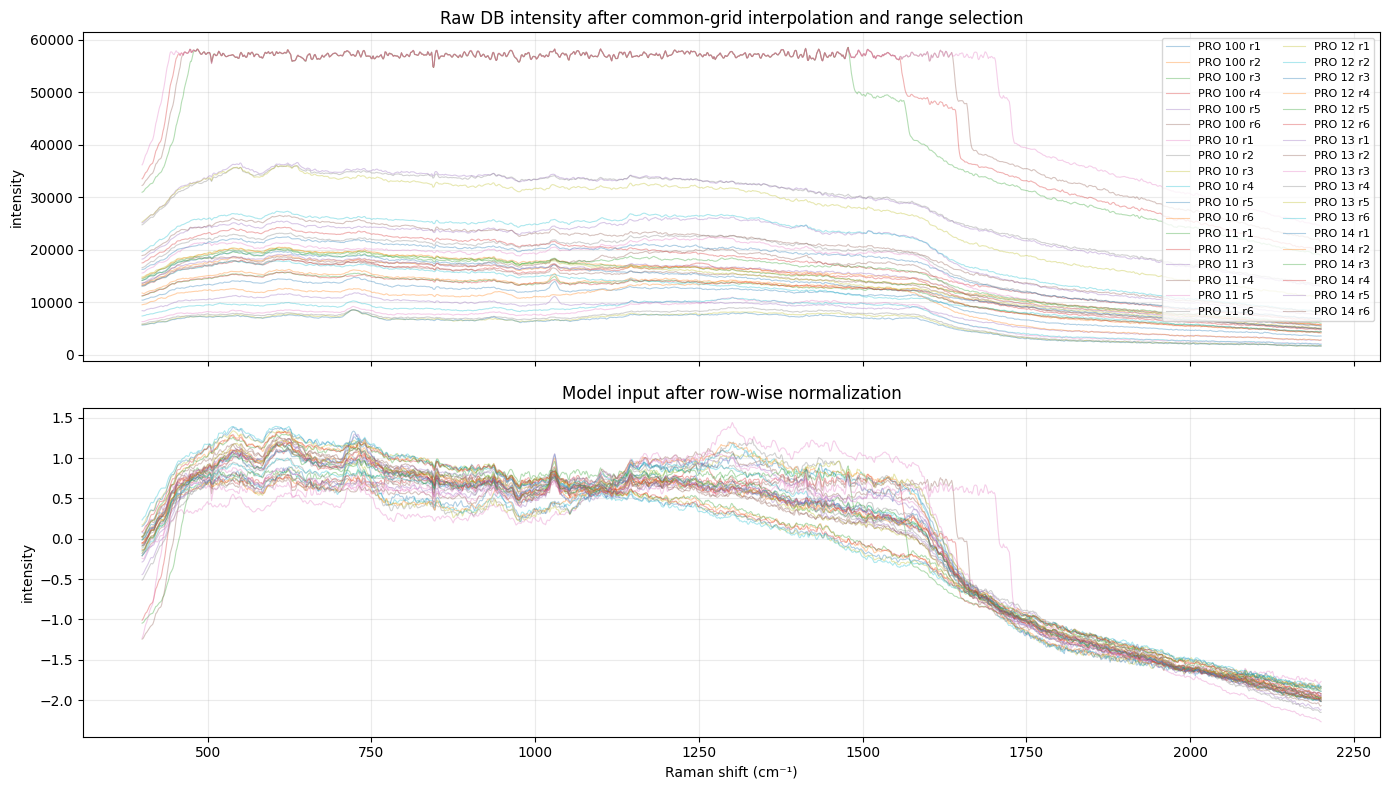

,source_path,source_batch,source_kind,group,sample_id,replicate,subject_id,raw_mean,raw_std,model_mean,model_std
0,medical/1. Prostate cancer (100개)/PRO 100_1.txt,1. Prostate cancer (100개),medical,PRO,100,1,medical::1. Prostate cancer (100개)::PRO::100,10344.207031,3486.105225,-2.372271e-07,1.0
1,medical/1. Prostate cancer (100개)/PRO 100_2.txt,1. Prostate cancer (100개),medical,PRO,100,2,medical::1. Prostate cancer (100개)::PRO::100,11666.331055,3820.998535,-2.033375e-07,1.0
2,medical/1. Prostate cancer (100개)/PRO 100_3.txt,1. Prostate cancer (100개),medical,PRO,100,3,medical::1. Prostate cancer (100개)::PRO::100,11480.128906,3590.675781,0.000000e+00,1.0
3,medical/1. Prostate cancer (100개)/PRO 100_4.txt,1. Prostate cancer (100개),medical,PRO,100,4,medical::1. Prostate cancer (100개)::PRO::100,13349.188477,4396.922852,-1.694480e-07,1.0
4,medical/1. Prostate cancer (100개)/PRO 100_5.txt,1. Prostate cancer (100개),medical,PRO,100,5,medical::1. Prostate cancer (100개)::PRO::100,8159.310547,2798.427979,0.000000e+00,1.0
5,medical/1. Prostate cancer (100개)/PRO 100_6.txt,1. Prostate cancer (100개),medical,PRO,100,6,medical::1. Prostate cancer (100개)::PRO::100,13105.899414,4084.632812,0.000000e+00,1.0
6,medical/1. Prostate cancer (100개)/PRO 10_1.txt,1. Prostate cancer (100개),medical,PRO,10,1,medical::1. Prostate cancer (100개)::PRO::10,6972.583984,2764.173096,3.388959e-08,1.0
7,medical/1. Prostate cancer (100개)/PRO 10_2.txt,1. Prostate cancer (100개),medical,PRO,10,2,medical::1. Prostate cancer (100개)::PRO::10,6104.290039,2385.227051,-1.694480e-07,1.0
8,medical/1. Prostate cancer (100개)/PRO 10_3.txt,1. Prostate cancer (100개),medical,PRO,10,3,medical::1. Prostate cancer (100개)::PRO::10,5803.975586,2245.814697,3.388959e-08,1.0
9,medical/1. Prostate cancer (100개)/PRO 10_4.txt,1. Prostate cancer (100개),medical,PRO,10,4,medical::1. Prostate cancer (100개)::PRO::10,7413.431641,2932.207031,-1.355584e-07,1.0


,source_batch,group,spectra,subjects,raw_std_median,model_std_median
0,1. Prostate cancer (100개),PRO,600,100,3335.994629,1.0
1,10-1. C-Pancreatic cancer (70개),CPAN,420,70,5959.695312,1.0
2,10-2. S-Pancreatic cancer (72개),SPAN,431,72,478.833008,1.0
3,10-3. Y-Pancreatic cancer (30개),YPAN,180,30,4437.542969,1.0
4,11. Bladdder Cancer (299개),BLC,1794,299,2899.096680,1.0
5,12. Y-Normal (29개),YNOR,174,29,3880.913086,1.0
6,2. Breast cancer (30개),BRE,180,30,2892.332520,1.0
7,3. Ovarian cancer (70개),OVA,420,70,5795.615234,1.0
8,4. Lung cancer (300개),LUN,1800,300,3974.231934,1.0
9,5. Normal (100개),NOR,2000,100,2371.211426,1.0


In [6]:
trace_subjects = metadata["subject_id"].drop_duplicates().head(PROCESS_TRACE_SUBJECTS)
trace_mask = metadata["subject_id"].isin(trace_subjects).to_numpy()
trace_indices = np.flatnonzero(trace_mask)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for index in trace_indices:
    row = metadata.iloc[index]
    label = f"{row['group']} {row['sample_id']} r{row['replicate']}"
    axes[0].plot(grid, aligned_values[index], alpha=0.35, linewidth=0.8, label=label)
    axes[1].plot(grid, X[index], alpha=0.35, linewidth=0.8, label=label)
axes[0].set_title("Raw DB intensity after common-grid interpolation and range selection")
axes[1].set_title("Model input after row-wise normalization")
axes[1].set_xlabel("Raman shift (cm⁻¹)")
for axis in axes:
    axis.set_ylabel("intensity")
    axis.grid(alpha=0.25)
axes[0].legend(loc="upper right", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

trace_columns = [
    column for column in [
        "source_path", "source_batch", "source_kind", "group", "sample_id", "replicate", "subject_id"
    ] if column in metadata.columns
]
trace_table = metadata.loc[trace_mask, trace_columns].copy()
trace_table["raw_mean"] = aligned_values[trace_mask].mean(axis=1)
trace_table["raw_std"] = aligned_values[trace_mask].std(axis=1)
trace_table["model_mean"] = X[trace_mask].mean(axis=1)
trace_table["model_std"] = X[trace_mask].std(axis=1)
display(trace_table)

profile_columns = ["source_batch", "group"] if "source_batch" in metadata.columns else ["group"]
batch_profile = metadata.assign(
    raw_mean=aligned_values.mean(axis=1),
    raw_std=aligned_values.std(axis=1),
    model_mean=X.mean(axis=1),
    model_std=X.std(axis=1),
).groupby(profile_columns, as_index=False).agg(
    spectra=("subject_id", "size"),
    subjects=("subject_id", "nunique"),
    raw_std_median=("raw_std", "median"),
    model_std_median=("model_std", "median"),
)
display(batch_profile.head(50))

### 3. Data checks and subject-level split

In [7]:
profile = metadata.assign(label=y).groupby(["group", "label"], as_index=False).agg(
    spectra=("subject_id", "size"),
    subjects=("subject_id", "nunique"),
)
display(profile)
assert len(X) == len(metadata) == len(y)
assert metadata["subject_id"].notna().all()
assert metadata.groupby("subject_id")["group"].nunique().max() == 1


def make_subject_splits(labels: np.ndarray, groups: pd.Series) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    groups_array = groups.to_numpy()
    outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    trainval_idx, test_idx = next(outer.split(np.zeros(len(labels)), labels, groups_array))
    inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED + 1)
    train_rel, val_rel = next(
        inner.split(np.zeros(len(trainval_idx)), labels[trainval_idx], groups_array[trainval_idx])
    )
    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel]
    return train_idx, val_idx, test_idx


train_idx, val_idx, test_idx = make_subject_splits(y, metadata["subject_id"])
train_subjects = set(metadata.iloc[train_idx]["subject_id"])
val_subjects = set(metadata.iloc[val_idx]["subject_id"])
test_subjects = set(metadata.iloc[test_idx]["subject_id"])
assert train_subjects.isdisjoint(val_subjects)
assert train_subjects.isdisjoint(test_subjects)
assert val_subjects.isdisjoint(test_subjects)
print({
    "train_rows_subjects": (len(train_idx), len(train_subjects)),
    "val_rows_subjects": (len(val_idx), len(val_subjects)),
    "test_rows_subjects": (len(test_idx), len(test_subjects)),
})

,group,label,spectra,subjects
0,BLC,0,1794,299
1,BRE,1,180,30
2,CPAN,2,420,70
3,CRC,3,1800,300
4,DIA,4,600,100
5,H.D.,5,600,100
6,HBP,6,600,100
7,LUN,7,1800,300
8,NOR,8,2000,100
9,OVA,9,420,70


{'train_rows_subjects': (7424, 1088), 'val_rows_subjects': (1856, 272), 'test_rows_subjects': (2319, 340)}


### 4. Model and training helpers

In [8]:
class SpectrumDataset(Dataset):
    def __init__(self, values: np.ndarray, labels: np.ndarray, augment: bool = False):
        self.values = torch.as_tensor(values, dtype=torch.float32)
        self.labels = torch.as_tensor(labels, dtype=torch.long)
        self.augment = augment

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        spectrum = self.values[index].unsqueeze(0)
        label = self.labels[index]
        if self.augment:
            spectrum = spectrum + torch.randn_like(spectrum) * TRAIN_NOISE_STD
            scale = torch.empty(1).uniform_(*TRAIN_SCALE_RANGE).item()
            spectrum = spectrum * scale
        return spectrum, label


class PaperCNN1D(nn.Module):
    """Paper-inspired 1D CNN with explicit pooling controls.

    The paper reports conv widths 16/32/64 and kernels 21/11/5, followed by a
    2048-unit tanh/dropout head.  Adaptive average pooling keeps the exploratory
    implementation valid for both the paper-like and native input lengths.
    """

    def __init__(
        self,
        n_classes: int,
        pool_kernel: int,
        pool_layers: int,
        use_batch_norm: bool = USE_BATCH_NORM,
    ):
        super().__init__()
        channels = [16, 32, 64]
        kernels = [21, 11, 5]
        blocks = []
        in_channels = 1
        for out_channels, kernel in zip(channels, kernels):
            layers: list[nn.Module] = [
                nn.Conv1d(in_channels, out_channels, kernel_size=kernel, padding=kernel // 2),
            ]
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(out_channels))
            layers.append(nn.LeakyReLU(negative_slope=0.01, inplace=True))
            blocks.append(nn.Sequential(*layers))
            in_channels = out_channels
        self.blocks = nn.ModuleList(blocks)
        self.pool_kernel = int(pool_kernel)
        self.pool_layers = int(pool_layers)
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Sequential(
            nn.Linear(64, 2048),
            nn.Tanh(),
            nn.Dropout(POOLING_DROPOUT),
            nn.Linear(2048, n_classes),
        )

    def forward(self, values: torch.Tensor) -> torch.Tensor:
        x = values
        for block_index, block in enumerate(self.blocks):
            x = block(x)
            if block_index < self.pool_layers:
                if x.shape[-1] < self.pool_kernel:
                    raise ValueError(
                        f"pool_kernel={self.pool_kernel} is too large at block {block_index}; "
                        "reduce pool_layers or kernel"
                    )
                x = F.max_pool1d(x, kernel_size=self.pool_kernel, stride=self.pool_kernel)
        x = self.global_pool(x).squeeze(-1)
        return self.head(x)


def make_loader(indices: np.ndarray, augment: bool, shuffle: bool) -> DataLoader:
    return DataLoader(
        SpectrumDataset(X[indices], y[indices], augment=augment),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    )


def class_weights(indices: np.ndarray) -> torch.Tensor | None:
    if CLASS_WEIGHTING == "none":
        return None
    if CLASS_WEIGHTING != "balanced":
        raise ValueError(f"Unsupported CLASS_WEIGHTING: {CLASS_WEIGHTING}")
    counts = np.bincount(y[indices], minlength=len(label_names)).astype(np.float32)
    weights = len(indices) / (len(label_names) * np.maximum(counts, 1.0))
    return torch.as_tensor(weights, dtype=torch.float32, device=DEVICE)


def predict_loader(model: nn.Module, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_probabilities: list[np.ndarray] = []
    all_labels: list[np.ndarray] = []
    with torch.no_grad():
        for batch_values, batch_labels in loader:
            logits = model(batch_values.to(DEVICE, non_blocking=True))
            all_probabilities.append(torch.softmax(logits, dim=1).cpu().numpy())
            all_labels.append(batch_labels.numpy())
    return np.concatenate(all_probabilities), np.concatenate(all_labels)


def top_k_accuracy(labels: np.ndarray, probabilities: np.ndarray, k: int) -> float:
    k = min(k, probabilities.shape[1])
    top_k = np.argsort(probabilities, axis=1)[:, -k:]
    return float(np.mean(np.any(top_k == labels[:, None], axis=1)))


def classification_metrics(labels: np.ndarray, probabilities: np.ndarray) -> dict[str, float]:
    predicted = probabilities.argmax(axis=1)
    metrics = {
        "accuracy": float(accuracy_score(labels, predicted)),
        "balanced_accuracy": float(balanced_accuracy_score(labels, predicted)),
        "macro_f1": float(
            f1_score(labels, predicted, labels=np.arange(len(label_names)), average="macro", zero_division=0)
        ),
        "top3_accuracy": top_k_accuracy(labels, probabilities, 3),
    }
    try:
        if len(label_names) == 2:
            metrics["auroc_ovr"] = float(roc_auc_score(labels, probabilities[:, 1]))
        else:
            metrics["auroc_ovr"] = float(
                roc_auc_score(labels, probabilities, multi_class="ovr", labels=np.arange(len(label_names)))
            )
    except ValueError:
        metrics["auroc_ovr"] = float("nan")
    return metrics


def subject_level_metrics(
    indices: np.ndarray, probabilities: np.ndarray, labels: np.ndarray
) -> tuple[dict[str, float], pd.DataFrame]:
    rows = metadata.iloc[indices][["subject_id", "group"]].copy()
    rows["label"] = labels
    for class_index in range(probabilities.shape[1]):
        rows[f"p_{class_index}"] = probabilities[:, class_index]
    aggregation = {"label": "first", **{f"p_{i}": "mean" for i in range(probabilities.shape[1])}}
    subjects = rows.groupby("subject_id", as_index=False).agg(aggregation)
    subject_probabilities = subjects[[f"p_{i}" for i in range(probabilities.shape[1])]].to_numpy()
    subject_labels = subjects["label"].to_numpy(dtype=np.int64)
    return classification_metrics(subject_labels, subject_probabilities), subjects


def train_one(config: dict[str, int | str]) -> dict[str, object]:
    set_seed(SEED)
    model = PaperCNN1D(
        n_classes=len(label_names),
        pool_kernel=int(config["pool_kernel"]),
        pool_layers=int(config["pool_layers"]),
    ).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights(train_idx))
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE
    )
    train_loader = make_loader(train_idx, augment=True, shuffle=True)
    val_loader = make_loader(val_idx, augment=False, shuffle=False)

    best_state = None
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    history: list[dict[str, float]] = []
    started = time.perf_counter()

    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_losses = []
        for batch_values, batch_labels in train_loader:
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_values.to(DEVICE, non_blocking=True))
            loss = criterion(logits, batch_labels.to(DEVICE, non_blocking=True))
            loss.backward()
            optimizer.step()
            train_losses.append(float(loss.detach().cpu()))

        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_values, batch_labels in val_loader:
                logits = model(batch_values.to(DEVICE, non_blocking=True))
                loss = criterion(logits, batch_labels.to(DEVICE, non_blocking=True))
                val_losses.append(float(loss.detach().cpu()))
        train_loss = float(np.mean(train_losses))
        val_loss = float(np.mean(val_losses))
        scheduler.step(val_loss)
        current_lr = float(optimizer.param_groups[0]["lr"])
        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "lr": current_lr})

        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            break

    if best_state is None:
        raise RuntimeError("No checkpoint was recorded")
    model.load_state_dict(best_state)
    val_probabilities, val_labels = predict_loader(model, val_loader)
    test_loader = make_loader(test_idx, augment=False, shuffle=False)
    test_probabilities, test_labels = predict_loader(model, test_loader)
    val_subject_metrics, _ = subject_level_metrics(val_idx, val_probabilities, val_labels)
    test_subject_metrics, test_subject_predictions = subject_level_metrics(
        test_idx, test_probabilities, test_labels
    )
    return {
        "config": config,
        "model": model,
        "state_dict": best_state,
        "history": pd.DataFrame(history),
        "val_metrics": val_subject_metrics,
        "test_metrics": test_subject_metrics,
        "test_subject_predictions": test_subject_predictions,
        "elapsed_seconds": time.perf_counter() - started,
    }


def predict_array(model: nn.Module, values: np.ndarray, labels: np.ndarray) -> np.ndarray:
    loader = DataLoader(
        SpectrumDataset(values, labels, augment=False),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=DEVICE.type == "cuda",
    )
    probabilities, _ = predict_loader(model, loader)
    return probabilities


def shift_spectra(values: np.ndarray, shift_cm: float, step_cm: float) -> np.ndarray:
    points = int(round(shift_cm / step_cm))
    if points == 0:
        return values.copy()
    shifted = np.zeros_like(values)
    if points > 0:
        shifted[:, points:] = values[:, :-points]
    else:
        shifted[:, :points] = values[:, -points:]
    return shifted


def shifted_subject_metrics(model: nn.Module, shift_cm: float) -> dict[str, float]:
    shifted_values = shift_spectra(X[test_idx], shift_cm, grid_step)
    probabilities = predict_array(model, shifted_values, y[test_idx])
    metrics, _ = subject_level_metrics(test_idx, probabilities, y[test_idx])
    return metrics

### 5. Shape sanity check

In [9]:
for candidate in EXPERIMENT_GRID[:MAX_CONFIGS]:
    candidate_model = PaperCNN1D(
        n_classes=len(label_names),
        pool_kernel=int(candidate["pool_kernel"]),
        pool_layers=int(candidate["pool_layers"]),
    ).to(DEVICE)
    with torch.no_grad():
        candidate_output = candidate_model(torch.zeros(2, 1, X.shape[1], device=DEVICE))
    parameter_count = sum(parameter.numel() for parameter in candidate_model.parameters())
    print(candidate["name"], {"output_shape": tuple(candidate_output.shape), "parameters": parameter_count})

m2_n1 {'output_shape': (2, 14), 'parameters': 178126}
m2_n3 {'output_shape': (2, 14), 'parameters': 178126}
m64_n1 {'output_shape': (2, 14), 'parameters': 178126}


### 6. Parameter sweep

In [10]:
results: dict[str, dict[str, object]] = {}
records: list[dict[str, object]] = []
for candidate in EXPERIMENT_GRID[:MAX_CONFIGS]:
    run = train_one(candidate)
    results[str(candidate["name"])] = run
    records.append({
        "config": candidate["name"],
        "pool_kernel_m": candidate["pool_kernel"],
        "pool_layers_n": candidate["pool_layers"],
        "best_val_macro_f1": run["val_metrics"]["macro_f1"],
        "test_accuracy": run["test_metrics"]["accuracy"],
        "test_balanced_accuracy": run["test_metrics"]["balanced_accuracy"],
        "test_macro_f1": run["test_metrics"]["macro_f1"],
        "test_top3_accuracy": run["test_metrics"]["top3_accuracy"],
        "test_auroc_ovr": run["test_metrics"]["auroc_ovr"],
        "seconds": run["elapsed_seconds"],
    })

sweep_results = pd.DataFrame(records).sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
display(sweep_results)

,config,pool_kernel_m,pool_layers_n,best_val_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_top3_accuracy,test_auroc_ovr,seconds
0,m64_n1,64,1,0.150966,0.294118,0.217857,0.172791,0.514706,0.718109,1.318990
1,m2_n1,2,1,0.108016,0.197059,0.185714,0.123221,0.347059,0.666740,1.870797
2,m2_n3,2,3,0.106647,0.229412,0.165476,0.113573,0.470588,0.659324,1.436208


### 7. Shift robustness of the best setting

In [11]:
best_config_name = str(sweep_results.iloc[0]["config"])
best_run = results[best_config_name]
best_model = best_run["model"]
shift_records = []
for shift_cm in EVAL_SHIFTS_CM:
    metrics = shifted_subject_metrics(best_model, shift_cm)
    shift_records.append({"shift_cm-1": shift_cm, **metrics})
shift_results = pd.DataFrame(shift_records)
display(shift_results)

,shift_cm-1,accuracy,balanced_accuracy,macro_f1,top3_accuracy,auroc_ovr
0,0.0,0.294118,0.217857,0.172791,0.514706,0.718109
1,3.0,0.291176,0.216667,0.171623,0.517647,0.718222
2,10.0,0.276471,0.203571,0.157688,0.520588,0.718740
3,15.0,0.282353,0.205952,0.160456,0.529412,0.718496
4,30.0,0.270588,0.201190,0.154618,0.514706,0.719718


### 8. Results and plots

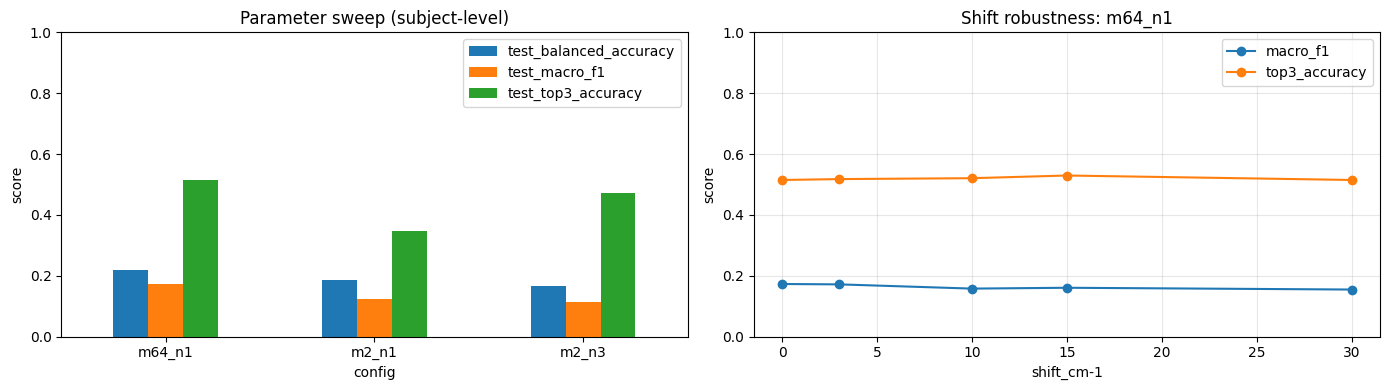

,epoch,train_loss,val_loss,lr
0,1,2.457187,2.468072,0.001
1,2,2.328076,2.378085,0.001
2,3,2.257175,2.316196,0.001


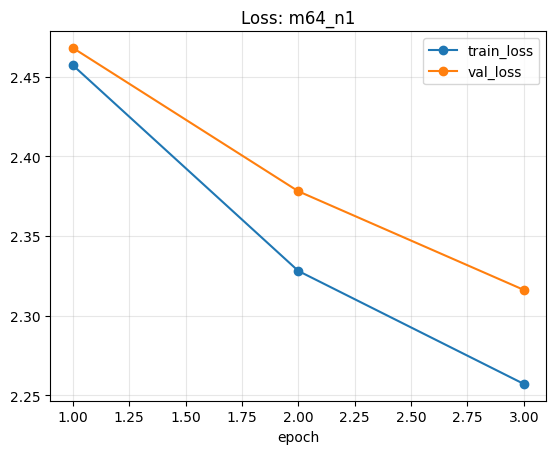

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sweep_results.set_index("config")[["test_balanced_accuracy", "test_macro_f1", "test_top3_accuracy"]].plot(
    kind="bar", ax=axes[0], ylim=(0, 1), title="Parameter sweep (subject-level)"
)
axes[0].set_ylabel("score")
axes[0].tick_params(axis="x", rotation=0)
shift_results.plot(x="shift_cm-1", y=["macro_f1", "top3_accuracy"], marker="o", ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title(f"Shift robustness: {best_config_name}")
axes[1].set_ylabel("score")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_history = best_run["history"]
display(best_history)
best_history.plot(x="epoch", y=["train_loss", "val_loss"], marker="o", title=f"Loss: {best_config_name}")
plt.grid(alpha=0.3)
plt.show()

## Takeaways

이 실험에서 먼저 볼 항목은 다음과 같습니다.

1. `test_macro_f1`와 `test_balanced_accuracy`가 함께 좋아지는 pooling 설정.
2. shift가 증가해도 `top3_accuracy`가 유지되는 설정.
3. validation과 test의 차이, 그리고 subject-level 결과가 row-level 결과보다
   과도하게 낙관적이지 않은지.
4. 선택된 설정을 `full` 모드로 재실행했을 때도 순위가 유지되는지.

이 결과만으로 임상 모델을 확정하지 말고, 다음 단계에서 암/비암 또는 cancer
type의 label 정의를 확정한 뒤 외부 병원·기기 holdout을 별도로 평가합니다.